# VRAE 모델 추론 및 시각화 분석

이 노트북은 학습된 VRAE 모델을 사용하여 특정 사용자의 미래 행동 궤적을 생성하고, 그 결과를 실제 데이터와 비교하여 시각화하는 과정을 담고 있습니다.

## 1. 설정 및 라이브러리 임포트

In [2]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import mlx.core as mx
from mlx.utils import tree_unflatten
import safetensors.mlx
import logging

# 프로젝트 루트 경로 설정
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

from models.model import VRAE
from scripts.train import TrajectoryDataset

# Hydra 설정 라이브러리
from hydra import initialize, compose
from omegaconf import OmegaConf

# 로거 설정
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

## 2. 실험 환경 설정 (Hydra)

분석할 `user_id`와 사용할 `checkpoint_path`를 여기서 수정하세요.

In [3]:
# Hydra 초기화 및 설정 로드
with initialize(version_base=None, config_path="./conf"):
    cfg = compose(config_name="config", overrides=[
        # ================== 여기를 수정하세요 ==================
        "inference.user_id=25",
        "inference.checkpoint_path=wandb/run-20251206_143843-tequvqay/files/checkpoints/model_epoch_10.safetensors"
        # ===================================================
    ])

print("===== Inference Configuration =====")
print(OmegaConf.to_yaml(cfg.inference))

===== Inference Configuration =====
user_id: 25
checkpoint_path: wandb/run-20251206_143843-tequvqay/files/checkpoints/model_epoch_10.safetensors
output_path: output/generated_trajectories.npz



## 3. 데이터 및 모델 로드

In [4]:
logger.info("Loading data...")
dataset = TrajectoryDataset(data_path=cfg.data.path, normalize=cfg.data.normalize)

logger.info("Initializing VRAE model...")
model = VRAE(
    action_dim=cfg.model.action_dim,
    state_dim=cfg.model.state_dim,
    context_dim=cfg.model.context_dim,
    latent_dim_a=cfg.model.latent_action_dim,
    latent_dim_b=cfg.model.latent_behavior_dim,
    latent_dim_c=cfg.model.latent_context_dim,
    rnn_hidden_dim=cfg.model.hidden_dim,
    k_a=cfg.model.k_a, k_b=cfg.model.k_b, k_c=cfg.model.k_c
)

logger.info(f"Loading weights from {cfg.inference.checkpoint_path}")
weights = safetensors.mlx.load_file(str(cfg.inference.checkpoint_path))
model.update(tree_unflatten(list(weights.items())))
model.eval()
mx.eval(model.parameters())
logger.info("Model loaded successfully.")

2025-12-06 16:43:04,915 - __main__ - INFO - Loading data...
2025-12-06 16:43:04,916 - scripts.train - INFO - Loading data from data/fitness_tracker_data.npz
2025-12-06 16:43:04,933 - scripts.train - INFO - Features shape: (999, 1000, 10)
2025-12-06 16:43:04,934 - scripts.train - INFO - Mask shape: (999, 1000, 1)
2025-12-06 16:43:04,935 - scripts.train - INFO - Mask validity: 63.42%
2025-12-06 16:43:04,949 - scripts.train - INFO - Action shape: (999, 1000, 7)
2025-12-06 16:43:04,949 - scripts.train - INFO - State shape: (999, 1000, 2)
2025-12-06 16:43:04,950 - scripts.train - INFO - Context shape: (999, 1000, 1)
2025-12-06 16:43:04,950 - scripts.train - INFO - Mask shape: (999, 1000, 1)
2025-12-06 16:43:04,956 - scripts.train - INFO - Normalized action[0]: mean=14973.17, std=8669.33
2025-12-06 16:43:04,962 - scripts.train - INFO - Normalized action[1]: mean=2745.07, std=730.36
2025-12-06 16:43:04,968 - scripts.train - INFO - Normalized action[2]: mean=9.97, std=5.78
2025-12-06 16:43:04,

## 4. 전체 사용자의 잠재 변수 분포 시각화

VRAE의 인코더를 사용하여 모든 사용자의 과거 행동 궤적을 잠재 변수(Latent Variable)로 압축합니다. 그 후, t-SNE를 이용해 고차원의 잠재 변수를 2차원으로 축소하여 사용자들이 잠재 공간 상에서 어떻게 분포하는지 시각화합니다. 이를 통해 사용자들의 행동 패턴이 어떻게 그룹화되는지 직관적으로 파악할 수 있습니다.

2025-12-06 16:28:42,192 - __main__ - INFO - Encoding all user trajectories to get latent variables...
100%|██████████| 999/999 [02:42<00:00,  6.13it/s]
2025-12-06 16:31:25,122 - __main__ - INFO - Latent variables shape (a, b, c): (999, 16), (999, 32), (999, 32)
2025-12-06 16:31:25,123 - __main__ - INFO - Running t-SNE for z_a...
2025-12-06 16:31:26,374 - __main__ - INFO - Running t-SNE for z_b...
2025-12-06 16:31:27,556 - __main__ - INFO - Running t-SNE for z_c...


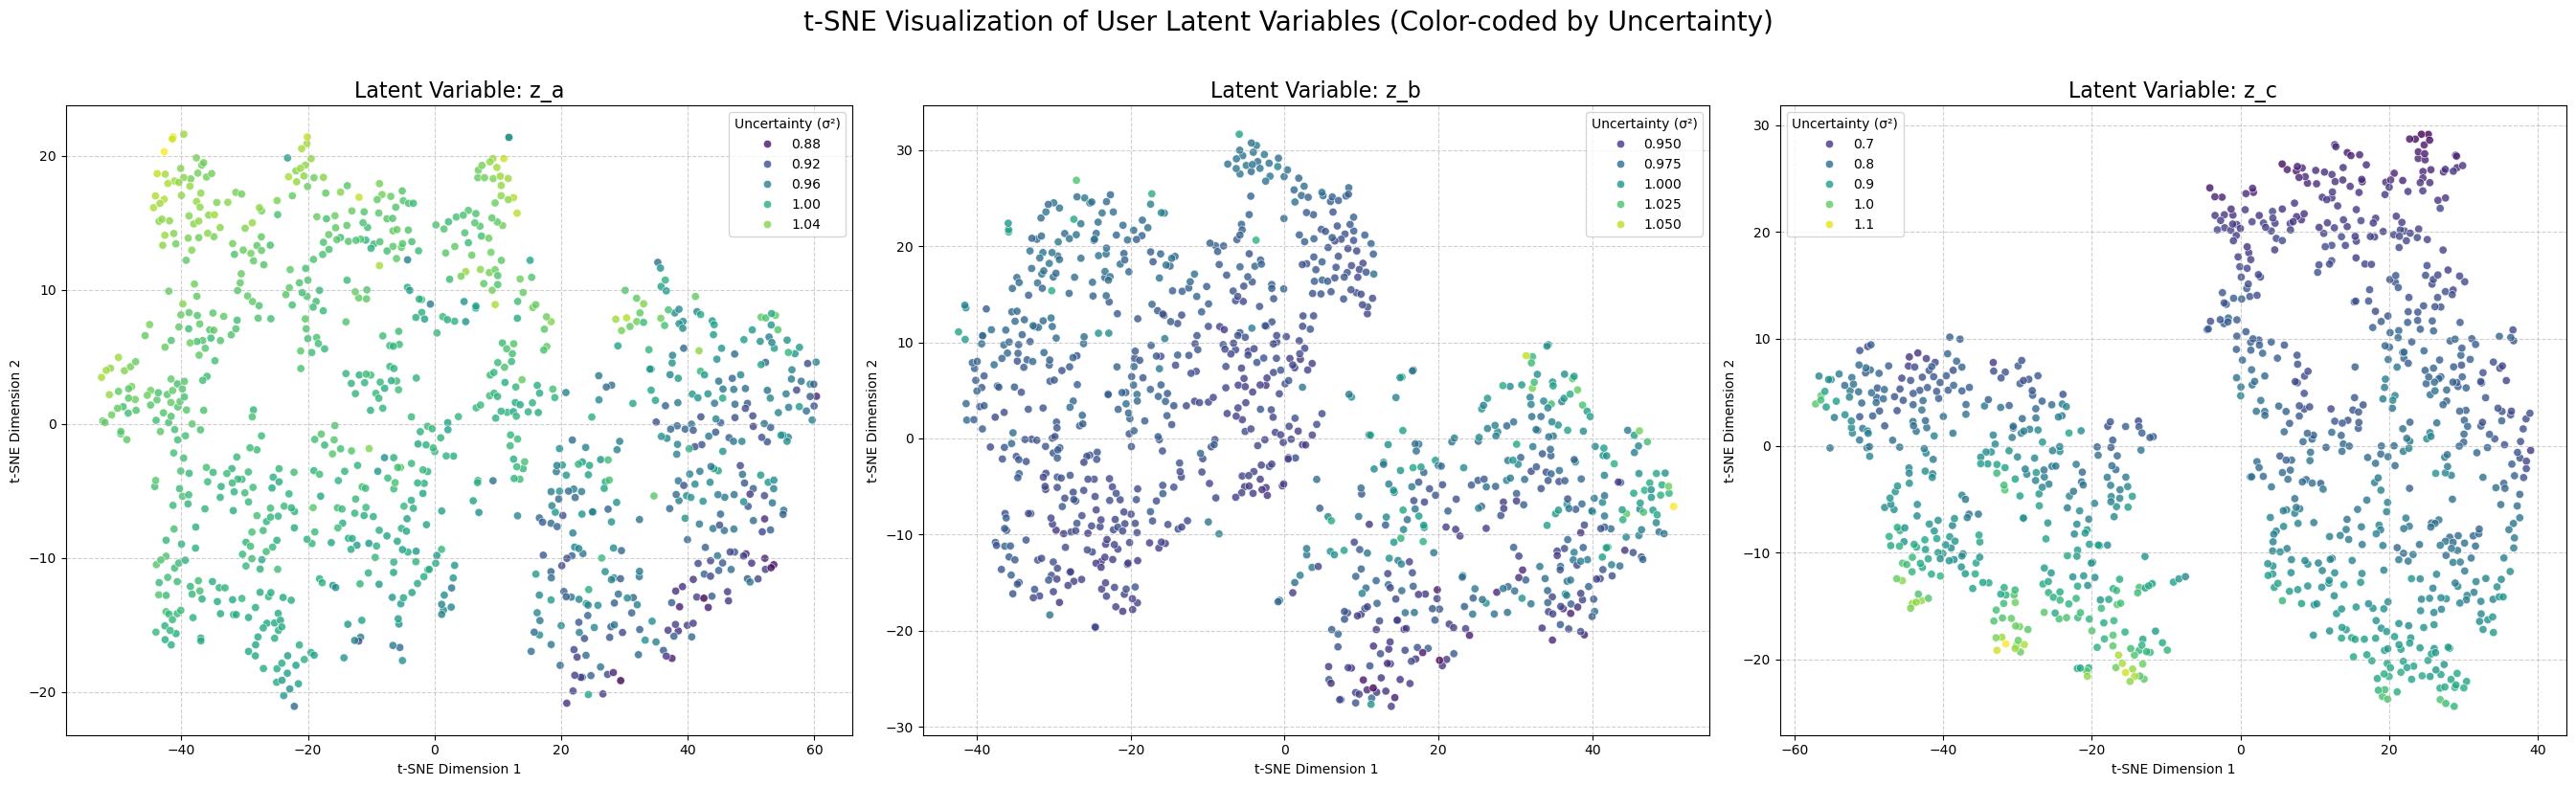

In [4]:
from sklearn.manifold import TSNE
import pandas as pd
import seaborn as sns
from tqdm import tqdm

logger.info("Encoding all user trajectories to get latent variables...")

latent_vars_a = []; latent_vars_b = []; latent_vars_c = []
log_sigma_sq_a = []; log_sigma_sq_b = []; log_sigma_sq_c = [] # VAE의 분산(σ^2) 값을 저장

# 모든 사용자에 대해 잠재 변수 추출
for user_id in tqdm(range(len(dataset))):
    user_data = dataset[user_id]
    past_a = mx.expand_dims(mx.array(user_data['action']), 0)
    past_s = mx.expand_dims(mx.array(user_data['state']), 0)
    past_w = mx.expand_dims(mx.array(user_data['context']), 0)
    past_m = mx.expand_dims(mx.array(user_data['mask']), 0)
    
    mu_a, log_sigma_a_sq, mu_b, log_sigma_b_sq, mu_c, log_sigma_c_sq = model.encode(past_a, past_s, past_w, past_m)
    
    latent_vars_a.append(np.array(mu_a.squeeze()))
    latent_vars_b.append(np.array(mu_b.squeeze()))
    latent_vars_c.append(np.array(mu_c.squeeze()))
    log_sigma_sq_a.append(np.array(log_sigma_a_sq.squeeze()).mean()) # 분산 값의 평균을 사용
    log_sigma_sq_b.append(np.array(log_sigma_b_sq.squeeze()).mean())
    log_sigma_sq_c.append(np.array(log_sigma_c_sq.squeeze()).mean())

latent_vars_a = np.array(latent_vars_a)
latent_vars_b = np.array(latent_vars_b)
latent_vars_c = np.array(latent_vars_c)

logger.info(f"Latent variables shape (a, b, c): {latent_vars_a.shape}, {latent_vars_b.shape}, {latent_vars_c.shape}")

# t-SNE로 2차원 축소
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
logger.info("Running t-SNE for z_a...")
z_a_2d = tsne.fit_transform(latent_vars_a)
logger.info("Running t-SNE for z_b...")
z_b_2d = tsne.fit_transform(latent_vars_b)
logger.info("Running t-SNE for z_c...")
z_c_2d = tsne.fit_transform(latent_vars_c)

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(27, 8))
fig.suptitle('t-SNE Visualization of User Latent Variables (Color-coded by Uncertainty)', fontsize=20, y=1.02)

latent_data = [(z_a_2d, log_sigma_sq_a, 'z_a'), (z_b_2d, log_sigma_sq_b, 'z_b'), (z_c_2d, log_sigma_sq_c, 'z_c')]

for i, (data, uncertainty, name) in enumerate(latent_data):
    scatter = sns.scatterplot(x=data[:, 0], y=data[:, 1], ax=axes[i], hue=uncertainty, palette='viridis', alpha=0.8, legend='auto')
    axes[i].set_title(f'Latent Variable: {name}', fontsize=16)
    axes[i].set_xlabel('t-SNE Dimension 1')
    axes[i].set_ylabel('t-SNE Dimension 2')
    axes[i].grid(True, linestyle='--', alpha=0.6)
    if axes[i].get_legend() is not None:
        axes[i].get_legend().set_title('Uncertainty (σ²)')

plt.tight_layout()
plt.show()

## 5. 기준 데이터 준비: 특정 사용자 잠재 변수 분포 추출

In [5]:
# 추론할 사용자 데이터 추출
user_id = cfg.inference.user_id
user_data = dataset[user_id]
past_a = mx.array(user_data['action'])
past_s = mx.array(user_data['state'])
past_w = mx.array(user_data['context'])
past_m = mx.array(user_data['mask'])

logger.info(f"Encoding past trajectory for user {user_id}...")
mu_a, sigma_a, mu_b, sigma_b, mu_c, sigma_c = model.encode(
    mx.expand_dims(past_a, 0), mx.expand_dims(past_s, 0),
    mx.expand_dims(past_w, 0), mx.expand_dims(past_m, 0)
)

# 배치 차원 제거
mu_a, sigma_a = mx.squeeze(mu_a, 0), mx.squeeze(sigma_a, 0)
mu_b, sigma_b = mx.squeeze(mu_b, 0), mx.squeeze(sigma_b, 0)
mu_c, sigma_c = mx.squeeze(mu_c, 0), mx.squeeze(sigma_c, 0)

# 롤아웃을 위한 초기값 설정
valid_indices = np.where(np.array(past_m).flatten() == 0)[0]
s0 = past_s[int(valid_indices[0])] if len(valid_indices) > 0 else past_s[0]
future_w = past_w

logger.info("Latent distributions (μ, σ) for z_a, z_b, z_c extracted.")

2025-12-06 16:43:08,211 - __main__ - INFO - Encoding past trajectory for user 25...
2025-12-06 16:43:08,291 - __main__ - INFO - Latent distributions (μ, σ) for z_a, z_b, z_c extracted.


## 6. 결과 시각화

In [8]:
ACTION_NAMES = [
    "sleep_hours", "workout_type", "location", "steps",
    "calories_burned", "distance_km", "active_minutes"
]

def plot_trajectories(trajectories: np.ndarray, actual_actions: np.ndarray, title: str, mask: np.ndarray = None):
    num_trajectories, T, action_dim = trajectories.shape
    mean_traj = np.mean(trajectories, axis=0)
    std_traj = np.std(trajectories, axis=0)

    fig, axes = plt.subplots(action_dim, 1, figsize=(20, 6 * action_dim), sharex=True)
    if action_dim == 1: axes = [axes] # 차원이 1일 때도 배열로 만듦

    fig.suptitle(title, fontsize=20, y=0.92)

    for i in range(action_dim):
        ax = axes[i]
        time_steps = np.arange(T)

        # 생성된 궤적들
        ax.plot(time_steps, trajectories[:, :, i].T, color='lightblue', alpha=0.3, linewidth=1.0)
        
        # 실제 궤적 (Ground Truth)
        if actual_actions is not None:
            actual_to_plot = actual_actions[:, i].copy()
            # 마스크가 제공되면, 유효하지 않은 데이터를 np.nan으로 변경
            if mask is not None:
                is_masked = (mask == 1).squeeze()
                actual_to_plot[is_masked] = np.nan # 마스킹된 위치를 np.nan으로 설정
            ax.plot(time_steps, actual_to_plot, color='black', linestyle='--', marker='o', markersize=2, linewidth=2.0, label='Actual Trajectory')

        # 평균 및 표준편차
        ax.plot(time_steps, mean_traj[:, i], color='red', linestyle='--', linewidth=2.5, label='Mean of Generated')
        ax.fill_between(time_steps, mean_traj[:, i] - std_traj[:, i], mean_traj[:, i] + std_traj[:, i], color='red', alpha=0.2, label='Std. Dev. of Generated')

        ax.set_title(f'Action: {ACTION_NAMES[i]}', fontsize=14)
        ax.set_ylabel('Value (Normalized)')
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend()

    axes[-1].set_xlabel('Time Step', fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()


### 6.1. 기본 추론 결과 (모든 잠재 변수 샘플링)

먼저 기존 `run.py`와 동일하게 모든 잠재 변수를 샘플링하여 궤적을 생성하고 시각화합니다. 이는 다른 실험들의 기준선(baseline)이 됩니다.

2025-12-06 16:51:22,418 - __main__ - INFO - Generating baseline trajectories (sampling all z)...


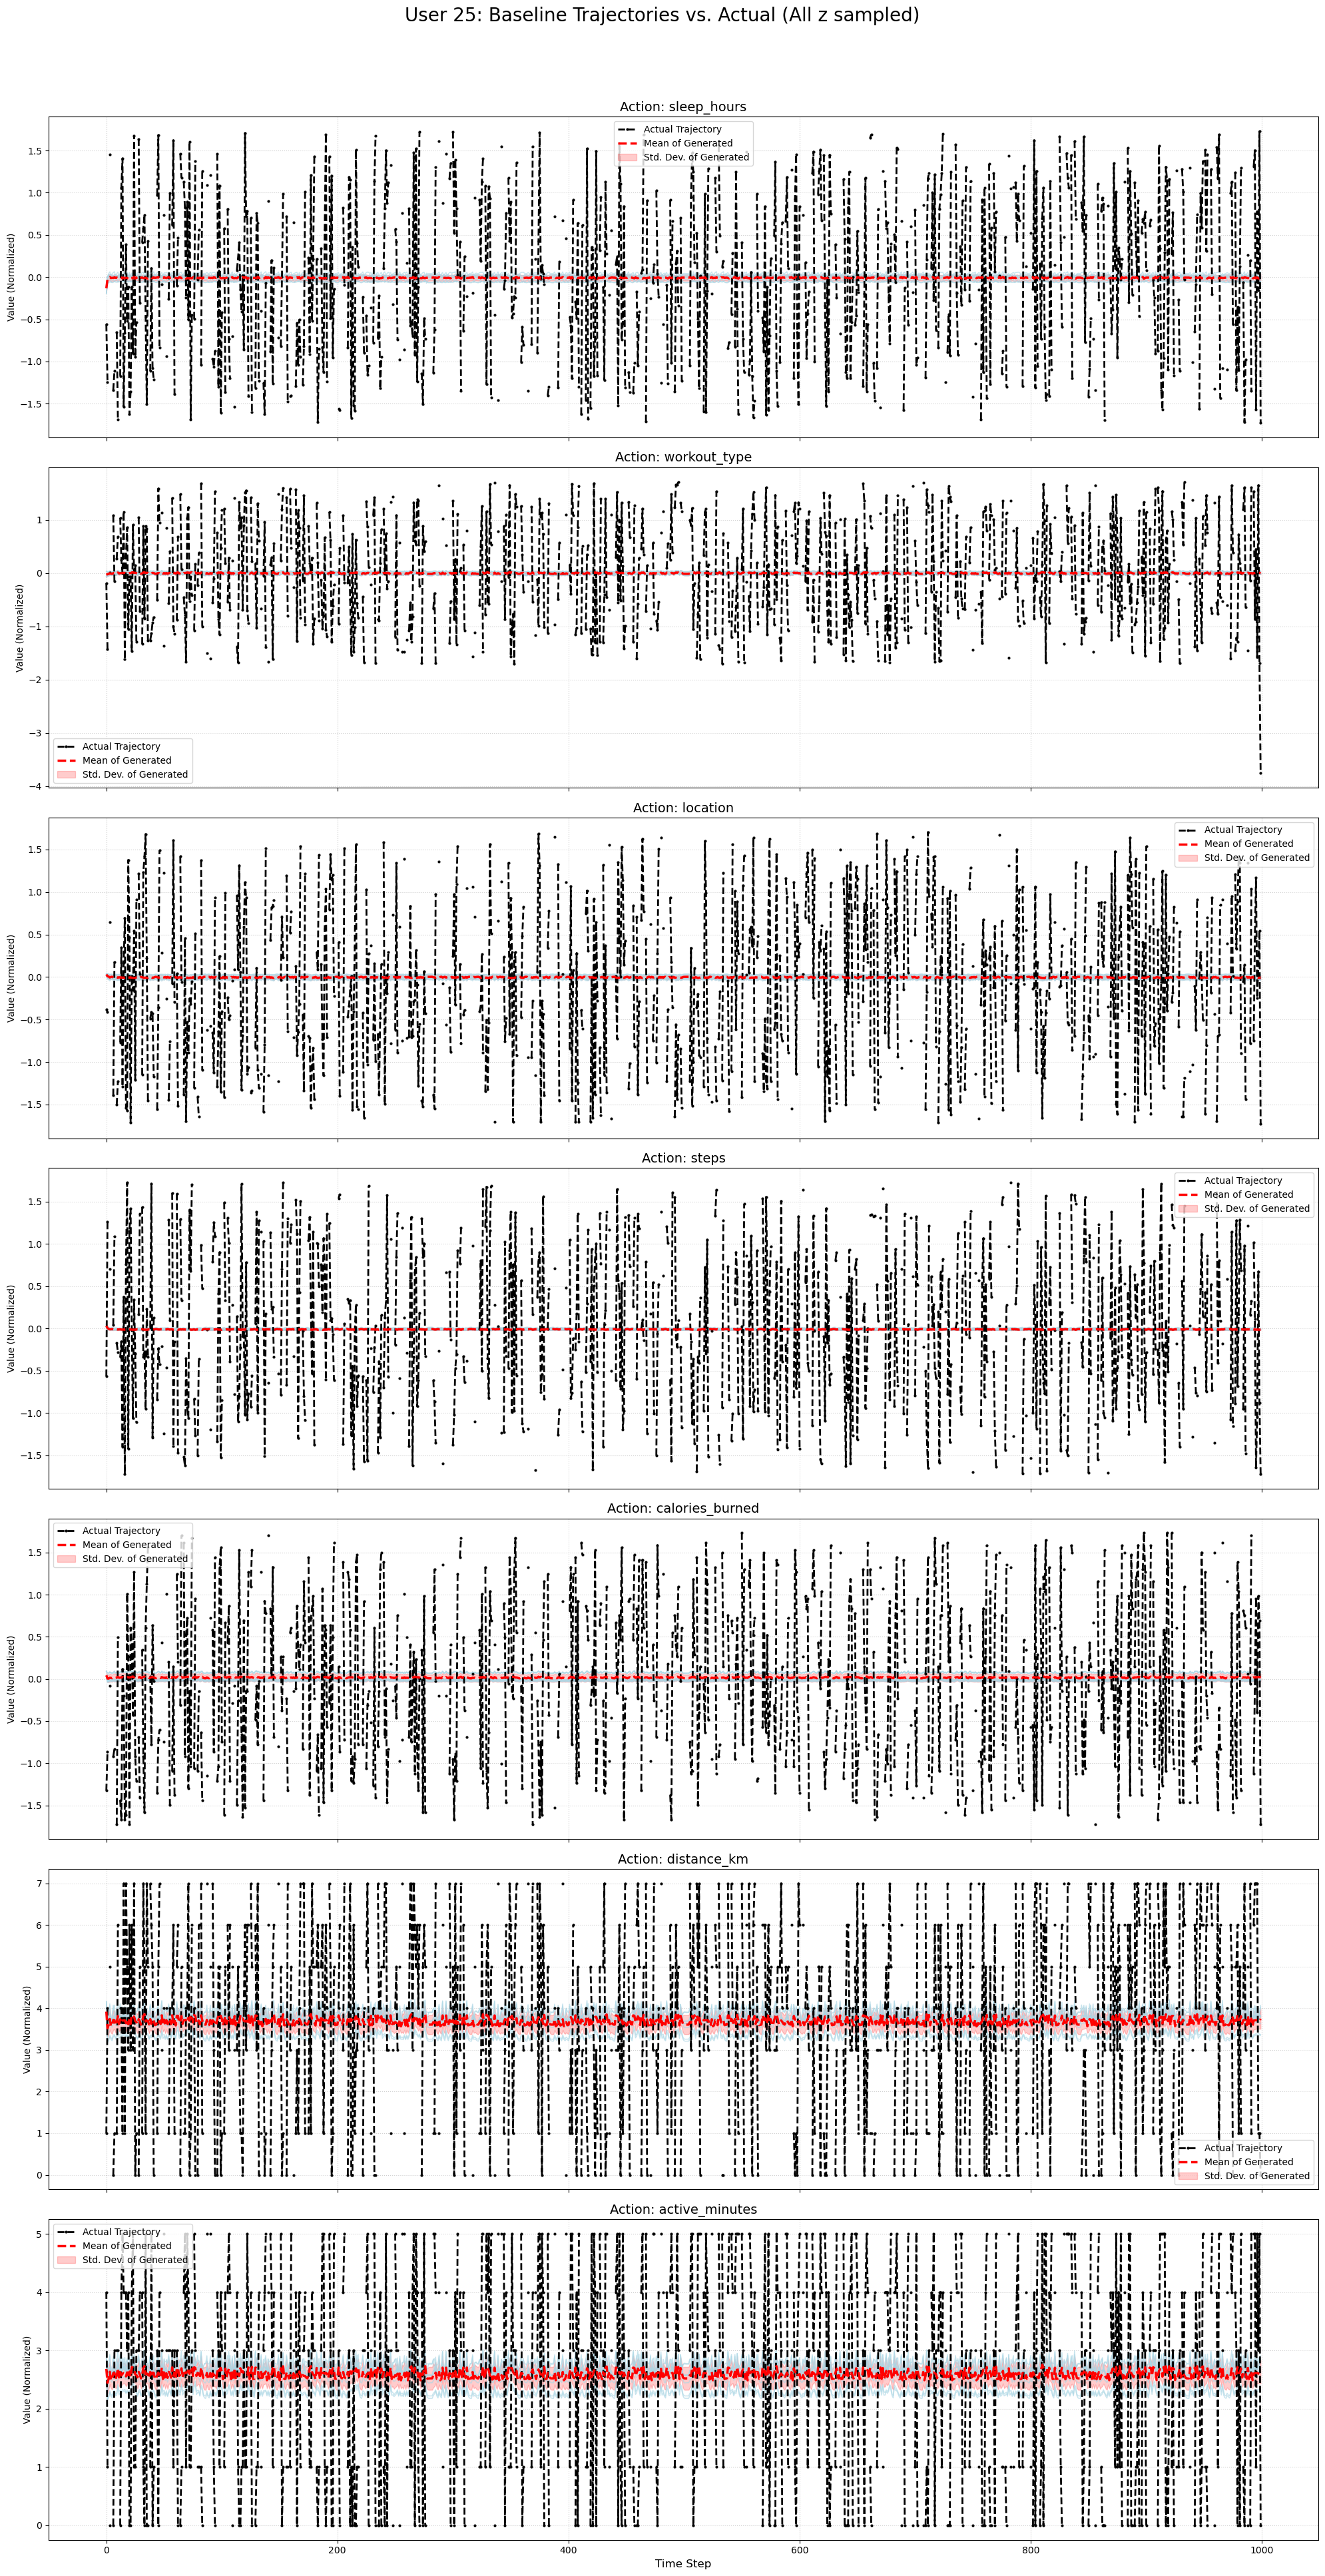

In [9]:
logger.info("Generating baseline trajectories (sampling all z)...")
trajectories_baseline = model.inference(
    s0, future_w, mu_a, sigma_a, mu_b, sigma_b, mu_c, sigma_c
)
mx.eval(trajectories_baseline)

plot_trajectories(
    np.array(trajectories_baseline),
    np.array(past_a),
    f'User {user_id}: Baseline Trajectories vs. Actual (All z sampled)',
    mask=np.array(past_m) # 마스크 데이터 전달
)


## 6. 잠재 변수 영향 분석

이제 각 스타일 변수(`z_a`, `z_b`, `z_c`)가 생성되는 궤적에 어떤 영향을 미치는지 개별적으로 분석합니다. 특정 변수를 샘플링하고 나머지는 평균(`mu`)으로 고정하여 그 효과를 명확히 확인합니다.

## 7. 결론

위 실험들을 통해 각 잠재 변수가 생성되는 궤적의 어떤 측면(초기 상태, 행동 패턴, 상태 변화)에 영향을 미치는지 시각적으로 확인할 수 있습니다. 이를 통해 모델이 사용자의 다양한 스타일을 어떻게 학습하고 분리해냈는지 깊이 있게 이해할 수 있습니다.